In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
df_instacart = pd.read_csv("../data/processed/instacart.csv")
df_instacart.head()

,Unnamed: 0.1,Unnamed: 0,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,...,Surname,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,0,0,1187899,11,4,8,14.0,1,1,Soda,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1,1,1187899,11,4,8,14.0,2,1,Organic String Cheese,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,2,2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,3,3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,4,4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [3]:
df_instacart.shape

(1384706, 23)

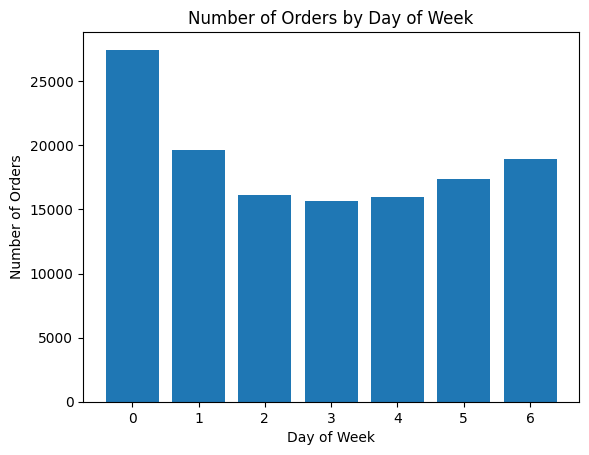

In [ ]:
# Analytical question: “On which days of the week are orders placed most frequently?”
orders_by_day = (
    df_instacart[['order_id', 'order_dow']]
    .drop_duplicates()
    .groupby('order_dow')
    .size()
)

plt.figure()
plt.bar(orders_by_day.index, orders_by_day.values)
plt.title("Number of Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.show()

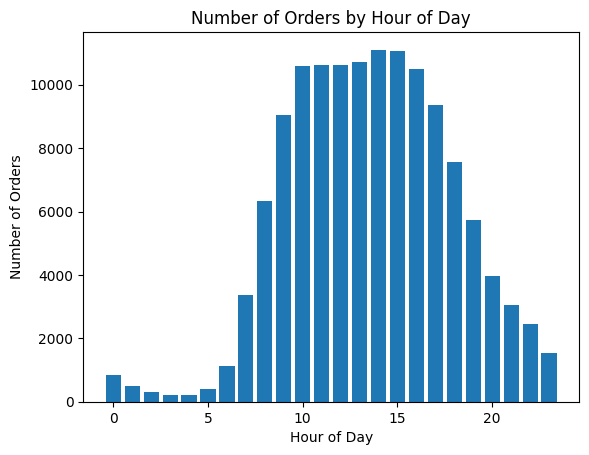

In [ ]:
# Analytical question: At what hours are orders placed most frequently?
order_by_hour = (
    df_instacart[['order_id', 'order_hour_of_day']]
    .drop_duplicates()
    .groupby('order_hour_of_day')
    .size()
)

plt.figure()
plt.bar(order_by_hour.index, order_by_hour.values)
plt.title("Number of Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.show()

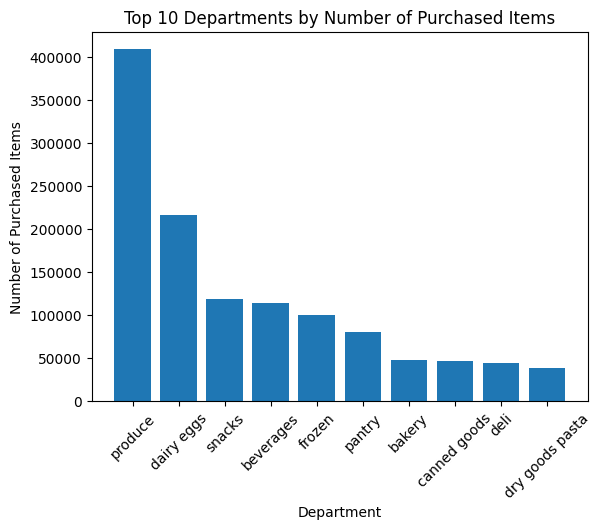

In [ ]:
# Analytical question: Which departments appear most often in the dataset?
top_departments = df_instacart["department"].value_counts().head(10)

plt.figure()
plt.bar(top_departments.index, top_departments.values)
plt.title("Top 10 Departments by Number of Purchased Items")
plt.xlabel("Department")
plt.ylabel("Number of Purchased Items")
plt.xticks(rotation=45)
plt.show()

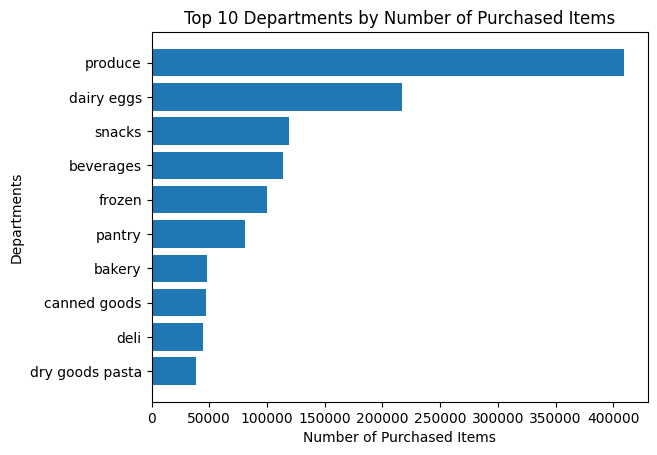

In [ ]:
# Analytical question: Which departments appear most often in the dataset?
top_departments_sorted = df_instacart["department"].value_counts().head(10).sort_values()

plt.figure()
plt.barh(top_departments_sorted.index, top_departments_sorted.values)
plt.title("Top 10 Departments by Number of Purchased Items")
plt.xlabel("Number of Purchased Items")
plt.ylabel("Departments")
plt.show()

In [ ]:
df_instacart["prices"].describe()

count    1.384618e+06
mean     1.411711e+01
std      6.802253e+02
min      1.000000e+00
25%      4.300000e+00
50%      7.400000e+00
75%      1.130000e+01
max      9.999900e+04
Name: prices, dtype: float64

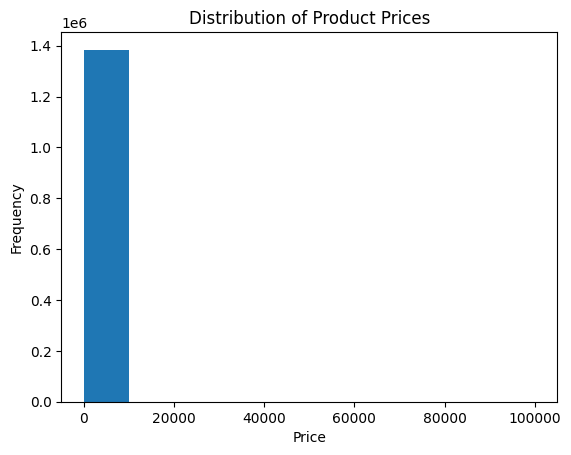

In [12]:
# Analytical question: How are product prices distributed?
plt.figure()
plt.hist(df_instacart["prices"].dropna(), bins=10)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Alternative 1: Using the 99th percentile
# Step 1: Calculate the upper quantile
upper_limit = df_instacart["prices"].quantile(0.99)
upper_limit

np.float64(18.1)

In [ ]:
# Step 2: Filter the data
df_prices_q = df_instacart[df_instacart["prices"] <= upper_limit]
df_prices_q["prices"].describe()

count    1.370887e+06
mean     7.668451e+00
std      4.039330e+00
min      1.000000e+00
25%      4.200000e+00
50%      7.300000e+00
75%      1.120000e+01
max      1.810000e+01
Name: prices, dtype: float64

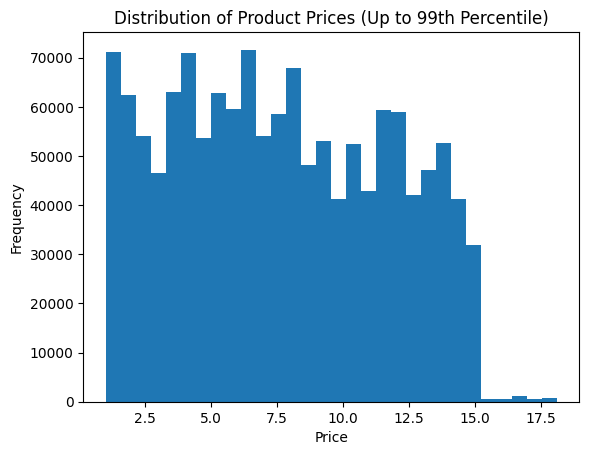

In [ ]:
# Step 3: Plot the trimmed distribution
plt.figure()
plt.hist(df_prices_q["prices"].dropna(), bins=30)
plt.title("Distribution of Product Prices (Up to 99th Percentile)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Alternative 2: Using the 95th percentile
# Step 1: Calculate the upper quantile
upper_limit_95 = df_instacart["prices"].quantile(0.95)
upper_limit_95

np.float64(14.3)

In [ ]:
# Step 2: Filter the data
df_prices_q95 = df_instacart[df_instacart["prices"] <= upper_limit_95]
df_prices_q95["prices"].describe

count    1.316686e+06
mean     7.373599e+00
std      3.843880e+00
min      1.000000e+00
25%      4.100000e+00
50%      7.100000e+00
75%      1.060000e+01
max      1.430000e+01
Name: prices, dtype: float64

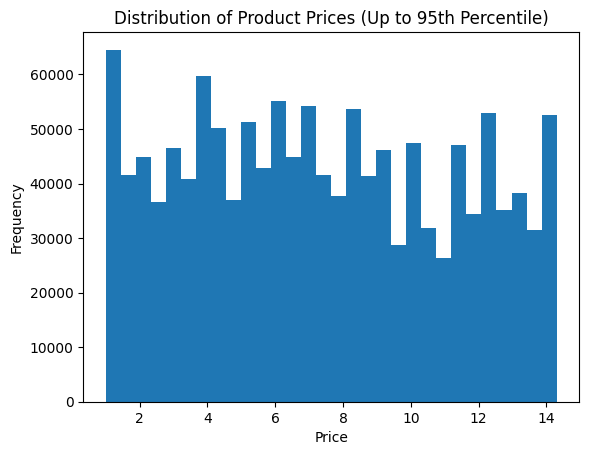

In [ ]:
# Step 3: Plot the trimmed distribution
plt.figure()
plt.hist(df_prices_q95["prices"].dropna(), bins=30)
plt.title("Distribution of Product Prices (Up to 95th Percentile)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

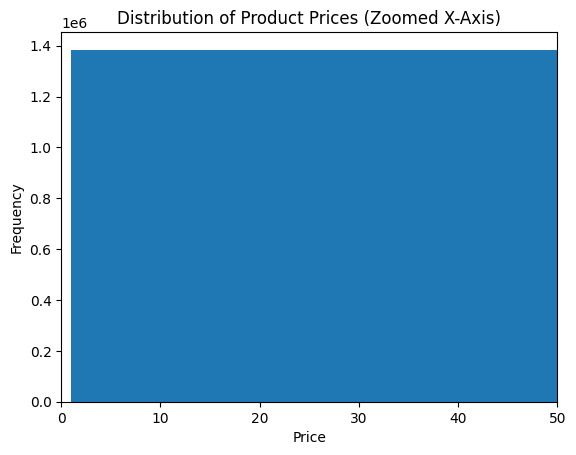

In [ ]:
# Alternative 3: Keeping all rows but zooming the x-axis
plt.figure()
plt.hist(df_instacart["prices"].dropna(), bins=30)
plt.xlim(0, 50)
plt.title("Distribution of Product Prices (Zoomed X-Axis)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

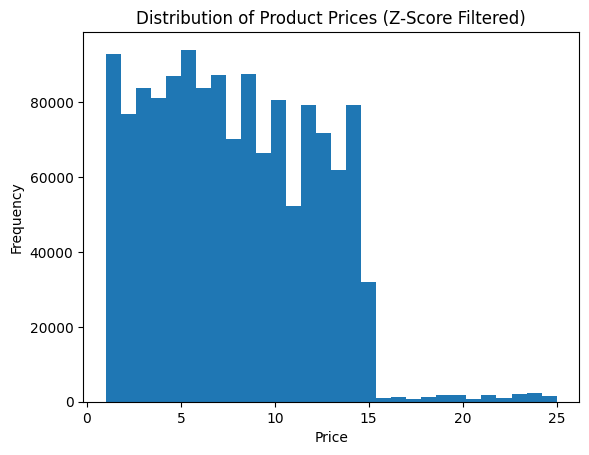

In [25]:
# Alternative 4: Using z-scores(z = (x - mean/std))
mean_price = df_instacart["prices"].mean()
std_price = df_instacart["prices"].std()

z_scores = (df_instacart["prices"] - mean_price) / std_price

df_prices_z = df_instacart[z_scores.abs() < 3]

plt.figure()
plt.hist(df_prices_z["prices"].dropna(), bins=30)
plt.title("Distribution of Product Prices (Z-Score Filtered)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [26]:
# Analytical question Which departments have the highest average prices?
avg_price_by_department = (
    df_instacart
    .groupby("department")["prices"]
    .mean()
    .sort_values(ascending=True)
)

avg_price_by_department

department
snacks              4.272277
other               7.184457
dry goods pasta     7.388252
household           7.402065
canned goods        7.530263
beverages           7.660526
babies              7.682672
deli                7.768707
international       7.799126
frozen              7.801781
bakery              7.833023
pets                7.867823
pantry              7.955316
personal care       7.989259
produce             7.997862
breakfast           8.090261
alcohol             8.126044
bulk                8.211626
missing             8.599139
meat seafood       16.202349
dairy eggs         48.606962
Name: prices, dtype: float64

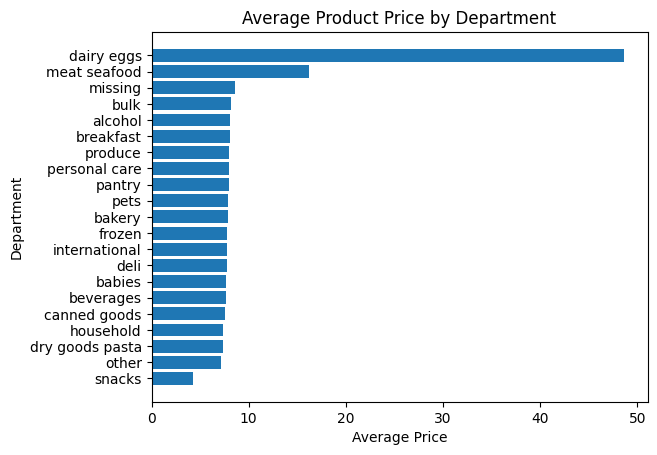

In [27]:
# Creating the chart
plt.figure()
plt.barh(avg_price_by_department.index, avg_price_by_department.values)
plt.title("Average Product Price by Department")
plt.xlabel("Average Price")
plt.ylabel("Department")
plt.show()

In [28]:
# Analytical question: Which regions have the highest reorder rate?
reorder_rate_by_region = (
    df_instacart
    .groupby("region")["reordered"]
    .mean()
    .sort_values(ascending=True)
)

reorder_rate_by_region

region
South        0.596392
Midwest      0.598615
West         0.599062
Northeast    0.602097
Name: reordered, dtype: float64

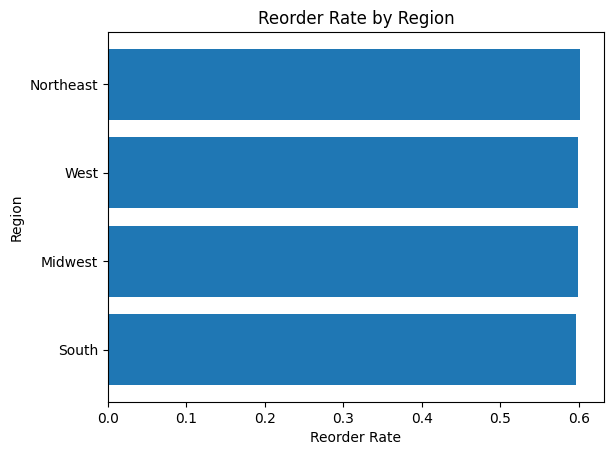

In [29]:
# Creating the chart
plt.figure()
plt.barh(reorder_rate_by_region.index, reorder_rate_by_region.values)
plt.title("Reorder Rate by Region")
plt.xlabel("Reorder Rate")
plt.ylabel("Region")
plt.show()

In [38]:
df_instacart.rename(columns={"Surnam": "Surname"}, inplace=True)

In [41]:
df_instacart.to_csv("../data/processed/instacart.csv")

In [43]:
# Analytical question: Is there a visible relationship between customer age and income?
customer_profile = df_instacart[
    ["First Name", "Surname", "Age", "income"]
].drop_duplicates()

customer_profile.head()

,First Name,Surname,Age,income
0,Linda,Nguyen,31,40423
11,Norma,Chapman,68,64940
42,Janet,Lester,75,115242
51,Peter,Villegas,39,89095
60,Anna,Allison,32,88603


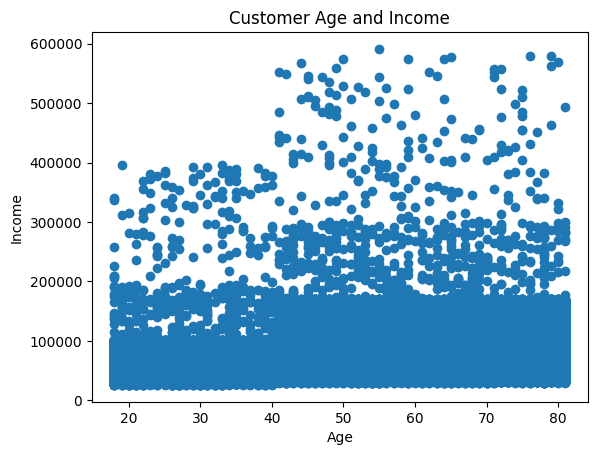

In [44]:
# Creating the chart
plt.figure()
plt.scatter(customer_profile["Age"], customer_profile["income"])
plt.title("Customer Age and Income")
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()